In [3]:
import pandas as pd
import pandas as pd
import numpy as np

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

**Reading the data**

In [6]:
train  = pd.read_csv("/content/JKIA 222.csv",encoding="latin_1")
train

,Serial No,Airline,Flight Letters,Flight Number,Departure Gate,Departure Date,Departure Month,Departure Time,Have you Made a transfer connection to this airport?,Destination Airport,...,Check-in 2,Check-in 3,Nationality,Country of Residence,Gender,Age group,ADDITIONAL COMMENTS,Flight Type,Terminal,Interviewer number
0,213010198,Kenya Airways,KQ,250,20B,26,July,1245,2,Seychelles,...,99,99,Spanish,Spain,2,3,NaN,1,T1A,3
1,213010269,Rwanda Airlines,WB,453,15,21,July,1120,2,Kigali,...,4,5,Rwandan,Rwanda,1,4,very intresting survey,1,T1A,3
2,213010189,Kenya Airways,KQ,2,23,26,July,2335,2,John F.Kennedy,...,99,99,Ghana,United States,1,7,It need more improvment and hardwork,1,T1A,3
3,213010172,Kenya Airways,KQ,2,23,26,July,2335,1,John F.Kennedy,...,99,99,Liberia,99,1,4,The management can work on the layover time,1,T1A,3
4,213010291,Emirates airlines,EK,720,5,21,July,1525,2,Dubai,...,2,99,Kenya,United Arab emirates,2,3,NaN,1,T2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,213010006,SAUDI ARABIAN AIRLINE,SV,430,18,8,9,13:30,1,JED,...,99,99,SOUTHAFRICAN,SOUTH AFRICA,2,5,friendly people. Comfortable seating with char...,1,1A,13
724,213010008,EMIRATES,EK,720,6,8,9,15:25,2,DXB,...,4,99,KENYAN,UAE,1,5,Excellent keep on improving.,1,2,11
725,213010351,EMIRATES,EK,720,6,8,9,15:25,2,DXB,...,5,6,UGANDAN,UGANDA,2,2,It's very good and flexible.It's even time fri...,1,2,11
726,213010007,EMIRATES,EK,720,6,8,9,15:25,2,DXB,...,99,99,KENYAN,KENYA,2,4,99,1,2,11


In [7]:
train.columns

Index(['Serial No', 'Airline ', 'Flight Letters', 'Flight Number',
       'Departure Gate', 'Departure Date', 'Departure Month', 'Departure Time',
       'Have you Made a transfer connection to this airport?',
       'Destination Airport', 'Main reason for Trip',
       'Section of aircraft you are travelling in',
       'Return trips made in the past 12 months',
       'Ground transport to/from the airport', 'Parking facilities',
       'VFM of parking facilities', 'Availability of baggage trolleys/carts',
       'Waiting time in check-in queue', 'Efficiency of check-in staff',
       'courtesy and helpfulness of check-in staff',
       'Waiting time at passport/ID inspection',
       'Courtesy/helpfulness of inspection staff',
       'Courtesy/helpfulness of security staff',
       'Thoroughness of security inspection staff',
       'Waiting time at security inspection',
       'Feeling of being safe and secure',
       'Ease of finding your way through airport',
       'Flight infor

#Importing Necesseties


In [8]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop=set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
import re
import string
import numpy as np 
import random
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter

from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


import nltk
from nltk.corpus import stopwords

from tqdm import tqdm
import os
import nltk
import spacy
import random
from spacy.util import compounding
from spacy.util import minibatch

import warnings
warnings.filterwarnings("ignore")

import os

In [10]:
def random_colours(number_of_colors):
    '''
    Simple function for random colours generation.
    Input:
        number_of_colors - integer value indicating the number of colours which are going to be generated.
    Output:
        Color in the following format: ['#E86DA4'] .
    '''
    colors = []
    for i in range(number_of_colors):
        colors.append("#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)]))
    return colors

In [11]:
print(train.shape)

(728, 65)


we have 728 comments for training

In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 65 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Serial No                                             728 non-null    int64  
 1   Airline                                               728 non-null    object 
 2   Flight Letters                                        728 non-null    object 
 3   Flight Number                                         728 non-null    int64  
 4   Departure Gate                                        728 non-null    object 
 5   Departure Date                                        728 non-null    int64  
 6   Departure Month                                       728 non-null    object 
 7   Departure Time                                        728 non-null    object 
 8   Have you Made a transfer connection to this airport?  728 no

# Droppin missing values in the training set

In [13]:
train.dropna(inplace=True)

In [ ]:
train.head()

,Serial No,Airline,Flight Letters,Flight Number,Departure Gate,Departure Date,Departure Month,Departure Time,Have you Made a transfer connection to this airport?,Destination Airport,...,Check-in 2,Check-in 3,Nationality,Country of Residence,Gender,Age group,ADDITIONAL COMMENTS,Flight Type,Terminal,Interviewer number
1,213010269,Rwanda Airlines,WB,453,15,21,July,1120,2,Kigali,...,4,5,Rwandan,Rwanda,1,4,very intresting survey,1,T1A,3
3,213010172,Kenya Airways,KQ,2,23,26,July,2335,1,John F.Kennedy,...,99,99,Liberia,99,1,4,The management can work on the layover time,1,T1A,3
8,213010297,Kenya Airways,KQ,310,19,22,July,1715,1,Dubai,...,99,99,Pakistan,Pakistan,1,4,overall the airport is good but the washroom s...,1,T1A,3
14,213010251,Kenya Airways,KQ,606,1,20,July,1200,2,Moi,...,99,99,Kenyan,Kenya,1,4,Good staff and comfortable,2,T1D,3
15,213010254,Jambo Jet,JM,8604,03B,20,July,1015,2,Moi,...,99,99,Kenyan,Kenya,1,4,improve the airport,2,T1D,3


#EDA

In [14]:
train.describe()

,Serial No,Flight Number,Departure Date,Have you Made a transfer connection to this airport?,Main reason for Trip,Section of aircraft you are travelling in,Return trips made in the past 12 months,Ground transport to/from the airport,Parking facilities,VFM of parking facilities,...,Speed of baggage delivery service,Customs inspection,Mode of transport to airport,Arrival time at the airport before departure time,Check-in 1,Check-in 2,Check-in 3,Gender,Age group,Interviewer number
count,5.270000e+02,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.00000,527.000000,...,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000
mean,2.122847e+08,1579.144213,11.037951,1.409867,2.187856,2.905123,1.483871,36.588235,44.56167,53.648956,...,44.220114,39.762808,38.430740,11.573055,18.925996,88.400380,96.149905,2.886148,4.984820,10.191651
std,1.179891e+07,2704.206010,6.996365,0.492276,0.841421,0.362858,0.794004,45.381602,47.22122,47.787952,...,47.152218,46.191397,46.295735,22.316891,35.908368,29.882995,16.122933,11.954219,11.753317,4.361437
min,2.130200e+07,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.00000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,3.000000
25%,2.130101e+08,416.000000,4.500000,1.000000,1.000000,3.000000,1.000000,3.000000,3.00000,3.000000,...,4.000000,4.000000,3.000000,6.000000,2.000000,99.000000,99.000000,1.000000,3.000000,3.000000
50%,2.130102e+08,578.000000,12.000000,1.000000,2.000000,3.000000,1.000000,5.000000,5.00000,99.000000,...,5.000000,5.000000,5.000000,7.000000,2.000000,99.000000,99.000000,1.000000,3.000000,11.000000
75%,2.130103e+08,756.000000,17.000000,2.000000,3.000000,3.000000,2.000000,99.000000,99.00000,99.000000,...,99.000000,99.000000,99.000000,7.000000,5.500000,99.000000,99.000000,2.000000,4.000000,14.000000
max,2.130600e+08,8712.000000,28.000000,2.000000,3.000000,3.000000,5.000000,99.000000,99.00000,99.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,14.000000


Checking the distribution of the training set

In [15]:
temp = train.groupby('sentiment').count()['text'].reset_index().sort_values(by='text',ascending=False)
temp.style.background_gradient(cmap='Purples')

,sentiment,text
1,positive,267
0,negative,260


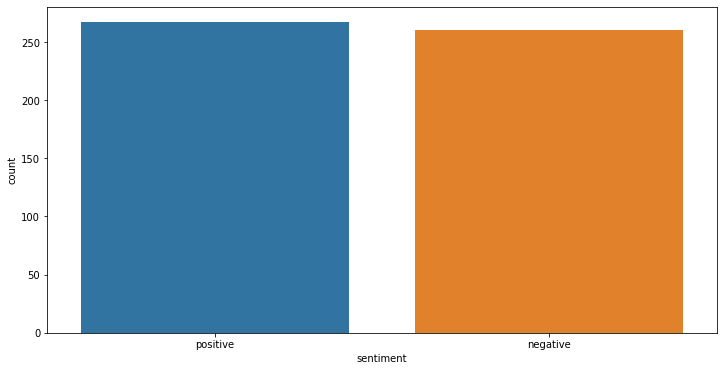

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(x='sentiment',data=train)

Funnel chart

In [17]:
fig = go.Figure(go.Funnelarea(text =temp.sentiment,values = temp.text,
    title = {"position": "top center", "text": "Funnel-Chart of Sentiment Distribution"}
    ))
fig.show()

In [18]:
def jaccard(str1, str2): 
    a = set(str1.lower().split()) 
    b = set(str2.lower().split())
    c = a.intersection(b)
    return float(len(c)) / (len(a) + len(b) - len(c))

In [19]:
results_jaccard=[]

for ind,row in train.iterrows():
    sentence1 = row.text
    sentence2 = row.text

    jaccard_score = jaccard(sentence1,sentence2)
    results_jaccard.append([sentence1,sentence2,jaccard_score])

In [20]:
train.head()

,Serial No,Airline,Flight Letters,Flight Number,Departure Gate,Departure Date,Departure Month,Departure Time,Have you Made a transfer connection to this airport?,Destination Airport,...,Check-in 2,Check-in 3,Nationality,Country of Residence,Gender,Age group,ADDITIONAL COMMENTS,Flight Type,Terminal,Interviewer number
1,213010269,Rwanda Airlines,WB,453,15,21,July,1120,2,Kigali,...,4,5,Rwandan,Rwanda,1,4,very intresting survey,1,T1A,3
3,213010172,Kenya Airways,KQ,2,23,26,July,2335,1,John F.Kennedy,...,99,99,Liberia,99,1,4,The management can work on the layover time,1,T1A,3
8,213010297,Kenya Airways,KQ,310,19,22,July,1715,1,Dubai,...,99,99,Pakistan,Pakistan,1,4,overall the airport is good but the washroom s...,1,T1A,3
14,213010251,Kenya Airways,KQ,606,1,20,July,1200,2,Moi,...,99,99,Kenyan,Kenya,1,4,Good staff and comfortable,2,T1D,3
15,213010254,Jambo Jet,JM,8604,03B,20,July,1015,2,Moi,...,99,99,Kenyan,Kenya,1,4,improve the airport,2,T1D,3


In [21]:
jaccard = pd.DataFrame(results_jaccard,columns=["text","selected_text","jaccard_score"])
train = train.merge(jaccard,how='outer')

In [22]:
train['Num_words_ST'] = train['selected_text'].apply(lambda x:len(str(x).split())) #Number Of words in Selected Text
train['Num_word_text'] = train['text'].apply(lambda x:len(str(x).split())) #Number Of words in main text
train['difference_in_words'] = train['Num_word_text'] - train['Num_words_ST'] #Difference in Number of words text and Selected Text

In [23]:
train.head()

,Serial No,Airline,Flight Letters,Flight Number,Departure Gate,Departure Date,Departure Month,Departure Time,Have you Made a transfer connection to this airport?,Destination Airport,...,Age group,ADDITIONAL COMMENTS,Flight Type,Terminal,Interviewer number,selected_text,jaccard_score,Num_words_ST,Num_word_text,difference_in_words
0,213010269,Rwanda Airlines,WB,453,15,21,July,1120,2,Kigali,...,4,very intresting survey,1,T1A,3,services,1.0,1,1,0
1,213010172,Kenya Airways,KQ,2,23,26,July,2335,1,John F.Kennedy,...,4,The management can work on the layover time,1,T1A,3,cleanliness of washroom and toilets,1.0,5,5,0
2,213010297,Kenya Airways,KQ,310,19,22,July,1715,1,Dubai,...,4,overall the airport is good but the washroom s...,1,T1A,3,Simple access,1.0,2,2,0
3,213010251,Kenya Airways,KQ,606,1,20,July,1200,2,Moi,...,4,Good staff and comfortable,2,T1D,3,Efficiency,1.0,1,1,0
4,213010251,Kenya Airways,KQ,606,1,20,July,1200,2,Moi,...,4,Good staff and comfortable,2,T1D,3,Efficiency,1.0,1,1,0


In [24]:
hist_data = [train['Num_words_ST'],train['Num_word_text']]

group_labels = ['Selected_Text', 'Text']

# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,show_curve=False)
fig.update_layout(title_text='Distribution of Number Of words')
fig.update_layout(
    autosize=False,
    width=900,
    height=700,
    paper_bgcolor="LightSteelBlue",
)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [25]:
hist_data = [train['Num_words_ST'],train['Num_word_text']]

group_labels = ['Selected_Text', 'Text']

# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,show_curve=False)
fig.update_layout(title_text='Distribution of Number Of words')
fig.update_layout(
    autosize=False,
    width=900,
    height=700,
    paper_bgcolor="LightSteelBlue",
)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

Distribution of words 

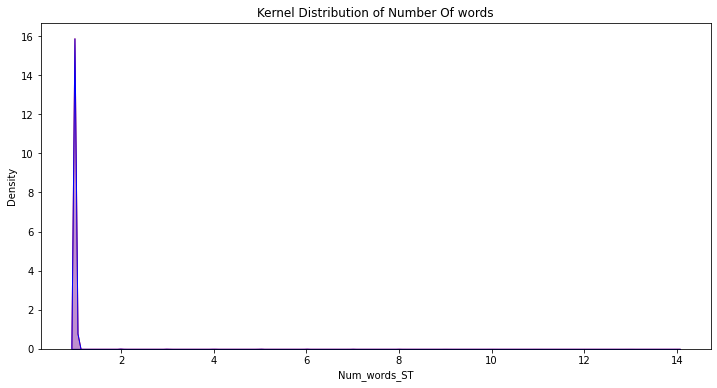

In [26]:
plt.figure(figsize=(12,6))
p1=sns.kdeplot(train['Num_words_ST'], shade=True, color="r").set_title('Kernel Distribution of Number Of words')
p1=sns.kdeplot(train['Num_word_text'], shade=True, color="b")

In [27]:
k = train[train['Num_word_text']<=2]

In [28]:
k.groupby('sentiment').mean()['jaccard_score']

sentiment
negative    1.0
positive    1.0
Name: jaccard_score, dtype: float64

Checking  the similarity between text and selected text 

In [29]:
k[k['sentiment']=='positive']

,Serial No,Airline,Flight Letters,Flight Number,Departure Gate,Departure Date,Departure Month,Departure Time,Have you Made a transfer connection to this airport?,Destination Airport,...,Age group,ADDITIONAL COMMENTS,Flight Type,Terminal,Interviewer number,selected_text,jaccard_score,Num_words_ST,Num_word_text,difference_in_words
0,213010269,Rwanda Airlines,WB,453,15,21,July,1120,2,Kigali,...,4,very intresting survey,1,T1A,3,services,1.0,1,1,0
2,213010297,Kenya Airways,KQ,310,19,22,July,1715,1,Dubai,...,4,overall the airport is good but the washroom s...,1,T1A,3,Simple access,1.0,2,2,0
3,213010251,Kenya Airways,KQ,606,1,20,July,1200,2,Moi,...,4,Good staff and comfortable,2,T1D,3,Efficiency,1.0,1,1,0
4,213010251,Kenya Airways,KQ,606,1,20,July,1200,2,Moi,...,4,Good staff and comfortable,2,T1D,3,Efficiency,1.0,1,1,0
5,213010116,Ethiopian Airlines,ET,319,13,16,8,18:30,2,ADD,...,3,99,1,1A,13,Efficiency,1.0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77452,213010346,KENYA AIRWAYS,KQ,604,1,7,9,13:00,2,MBA,...,3,99,2,1D,3,Service,1.0,1,1,0
77453,213010349,KENYA AIRWAYS,KQ,352,16,7,9,12:55,2,JUB,...,4,99,1,1A,3,Parking facilities,1.0,2,2,0
77455,213010339,JAMBO JET,JM,8692,2,7,9,12:55,2,UKA,...,5,99,2,1D,13,Courtesy staff,1.0,2,2,0
77456,213010357,KENYA AIRWAYS,KQ,756,16,8,9,12:30,1,LLW,...,4,Washrooms need muslim shower,1,1A,13,Exchange money,1.0,2,2,0


In [30]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [31]:
train['text'] = train['text'].apply(lambda x:clean_text(x))
train['selected_text'] = train['selected_text'].apply(lambda x:clean_text(x))

Most Common words in our Target-Selected Text

In [32]:
train['temp_list'] = train['selected_text'].apply(lambda x:str(x).split())
top = Counter([item for sublist in train['temp_list'] for item in sublist])
temp = pd.DataFrame(top.most_common(20))
temp.columns = ['Common_words','count']
temp.style.background_gradient(cmap='Blues')

,Common_words,count
0,the,49
1,staff,40
2,of,33
3,in,32
4,and,29
5,check,21
6,waiting,20
7,to,17
8,internet,17
9,was,17


Removing the stopwords

In [33]:
def remove_stopword(x):
    return [y for y in x if y not in stopwords.words('english')]
train['temp_list'] = train['temp_list'].apply(lambda x:remove_stopword(x))

In [34]:
top = Counter([item for sublist in train['temp_list'] for item in sublist])
temp = pd.DataFrame(top.most_common(20))
temp = temp.iloc[1:,:]
temp.columns = ['Common_words','count']
temp.style.background_gradient(cmap='Purples')

,Common_words,count
1,check,21
2,waiting,20
3,internet,17
4,wifi,17
5,security,16
6,courtesy,13
7,time,13
8,airport,13
9,facilities,11
10,service,11


In [35]:
fig = px.treemap(temp, path=['Common_words'], values='count',title='Tree of Most Common Words')
fig.show()

In [36]:
train['temp_list1'] = train['text'].apply(lambda x:str(x).split()) #List of words in every row for text
train['temp_list1'] = train['temp_list1'].apply(lambda x:remove_stopword(x)) #Removing Stopwords

In [37]:
top = Counter([item for sublist in train['temp_list1'] for item in sublist])
temp = pd.DataFrame(top.most_common(25))
temp = temp.iloc[1:,:]
temp.columns = ['Common_words','count']
temp.style.background_gradient(cmap='Blues')

,Common_words,count
1,check,21
2,waiting,20
3,internet,17
4,wifi,17
5,security,16
6,courtesy,13
7,time,13
8,airport,13
9,facilities,11
10,service,11


In [38]:
fig = px.bar(temp, x="count", y="Common_words", title='Commmon Words in Text', orientation='h', 
             width=700, height=700,color='Common_words')
fig.show()

#Most common words Sentiments Wise

In [39]:
Positive_sent = train[train['sentiment']=='positive']
Negative_sent = train[train['sentiment']=='negative']
Neutral_sent = train[train['sentiment']=='neutral']

Most common positive words

In [40]:
#MosT common positive words
top = Counter([item for sublist in Positive_sent['temp_list'] for item in sublist])
temp_positive = pd.DataFrame(top.most_common(20))
temp_positive.columns = ['Common_words','count']
temp_positive.style.background_gradient(cmap='Greens')

,Common_words,count
0,staff,37
1,internet,14
2,check,13
3,wifi,13
4,waiting,11
5,courtesy,11
6,service,11
7,security,10
8,helpfulness,9
9,helpful,9


In [41]:
fig = px.bar(temp_positive, x="count", y="Common_words", title='Most Commmon Positive Words', orientation='h', 
             width=700, height=700,color='Common_words')
fig.show()

Most common negative words

In [42]:
#MosT common negative words
top = Counter([item for sublist in Negative_sent['temp_list'] for item in sublist])
temp_negative = pd.DataFrame(top.most_common(20))
temp_negative = temp_negative.iloc[1:,:]
temp_negative.columns = ['Common_words','count']
temp_negative.style.background_gradient(cmap='Reds')

,Common_words,count
1,waiting,9
2,check,8
3,flight,8
4,facilities,7
5,security,6
6,airport,5
7,time,5
8,water,5
9,toilet,5
10,food,5


In [43]:
fig = px.treemap(temp_negative, path=['Common_words'], values='count',title='Tree Of Most Common Negative Words')
fig.show()

#Unique Words in each Segment

In [44]:
raw_text = [word for word_list in train['temp_list1'] for word in word_list]

In [45]:
def words_unique(sentiment,numwords,raw_words):
    '''
    Input:
        segment - Segment category (ex. 'Neutral');
        numwords - how many specific words do you want to see in the final result; 
        raw_words - list  for item in train_data[train_data.segments == segments]['temp_list1']:
    Output: 
        dataframe giving information about the name of the specific ingredient and how many times it occurs in the chosen cuisine (in descending order based on their counts)..

    '''
    allother = []
    for item in train[train.sentiment != sentiment]['temp_list1']:
        for word in item:
            allother .append(word)
    allother  = list(set(allother ))
    
    specificnonly = [x for x in raw_text if x not in allother]
    
    mycounter = Counter()
    
    for item in train[train.sentiment == sentiment]['temp_list1']:
        for word in item:
            mycounter[word] += 1
    keep = list(specificnonly)
    
    for word in list(mycounter):
        if word not in keep:
            del mycounter[word]
    
    Unique_words = pd.DataFrame(mycounter.most_common(numwords), columns = ['words','count'])
    
    return Unique_words

Positive comments

In [46]:
Unique_Positive= words_unique('positive', 20, raw_text)
print("The top 20 unique words in Positive comments are:")
Unique_Positive.style.background_gradient(cmap='Greens')

The top 20 unique words in Positive comments are:


,words,count
0,service,11
1,helpfulness,9
2,helpful,9
3,friendly,8
4,efficiency,7
5,customer,7
6,best,6
7,good,6
8,cleanliness,5
9,ease,4


In [47]:
fig = px.treemap(Unique_Positive, path=['words'], values='count',title='Tree Of Unique Positive Words')
fig.show()

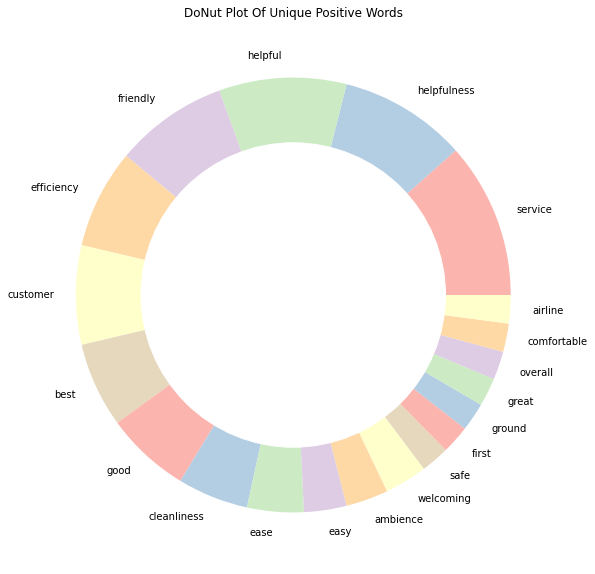

In [48]:
from palettable.colorbrewer.qualitative import Pastel1_7
plt.figure(figsize=(16,10))
my_circle=plt.Circle((0,0), 0.7, color='white')
plt.pie(Unique_Positive['count'], labels=Unique_Positive.words, colors=Pastel1_7.hex_colors)
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.title('DoNut Plot Of Unique Positive Words')
plt.show()

In [49]:
Unique_Negative= words_unique('negative', 10, raw_text)
print("The top 10 unique words in Negative comments are:")
Unique_Negative.style.background_gradient(cmap='Reds')

The top 10 unique words in Negative comments are:


,words,count
0,water,5
1,toilet,5
2,food,5
3,enough,3
4,working,3
5,poor,3
6,gate,3
7,layover,2
8,connectivity,2
9,transit,2


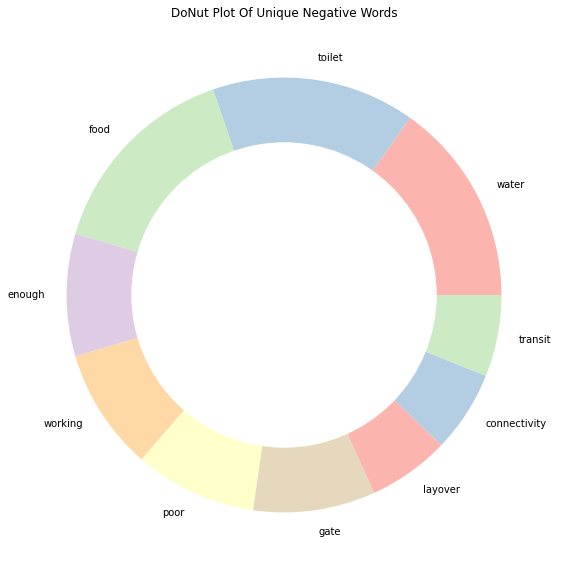

In [50]:
from palettable.colorbrewer.qualitative import Pastel1_7
plt.figure(figsize=(16,10))
my_circle=plt.Circle((0,0), 0.7, color='white')
plt.rcParams['text.color'] = 'black'
plt.pie(Unique_Negative['count'], labels=Unique_Negative.words, colors=Pastel1_7.hex_colors)
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.title('DoNut Plot Of Unique Negative Words')
plt.show()

**It's Time For WordClouds**

In [54]:
def plot_wordcloud(text, mask=None, max_words=200, max_font_size=100, figure_size=(15.0,8.0), color = 'white',
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'u', "im"}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color=color,
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size, 
                    random_state = 42,
                    width=200, 
                    height=100,
                    mask = mask)
    wordcloud.generate(str(text))
    
    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask);
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
        plt.title(title, fontdict={'size': title_size,  
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud);
        plt.title(title, fontdict={'size': title_size, 'color': 'black', 
                                  'verticalalignment': 'bottom'})
    plt.axis('off');
    plt.tight_layout()  
d = '/content/sample_data'

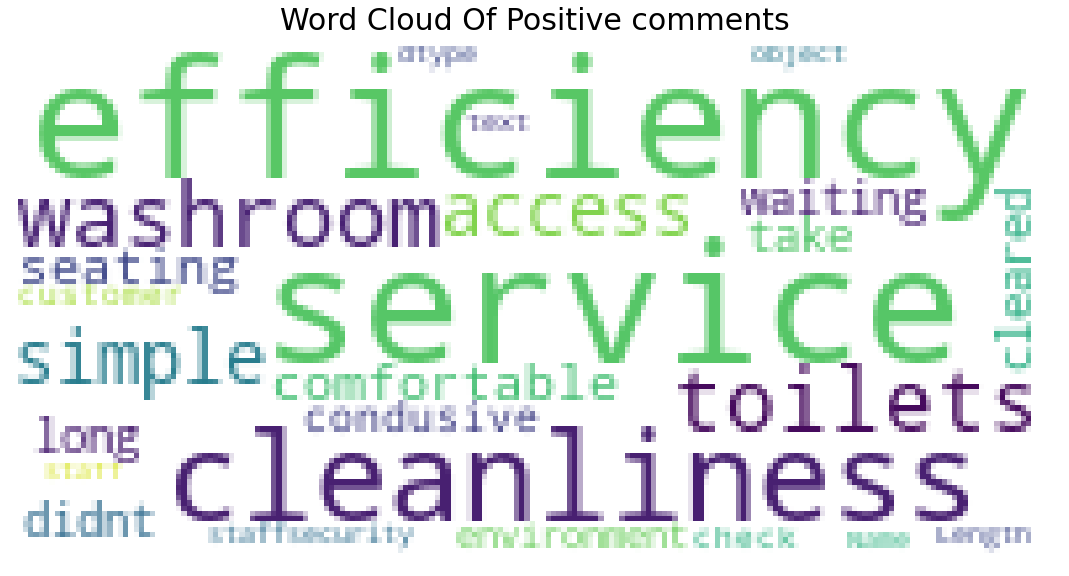

In [55]:
plot_wordcloud(Positive_sent.text,title="Word Cloud Of Positive comments",title_size=30)

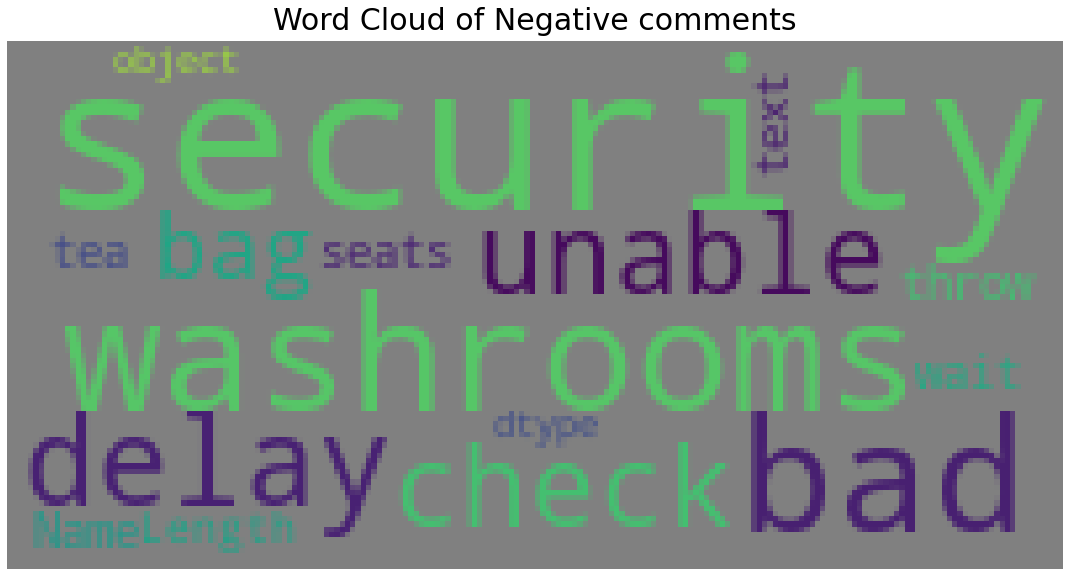

In [56]:
plot_wordcloud(Negative_sent.text,title="Word Cloud of Negative comments",color='grey',title_size=30)

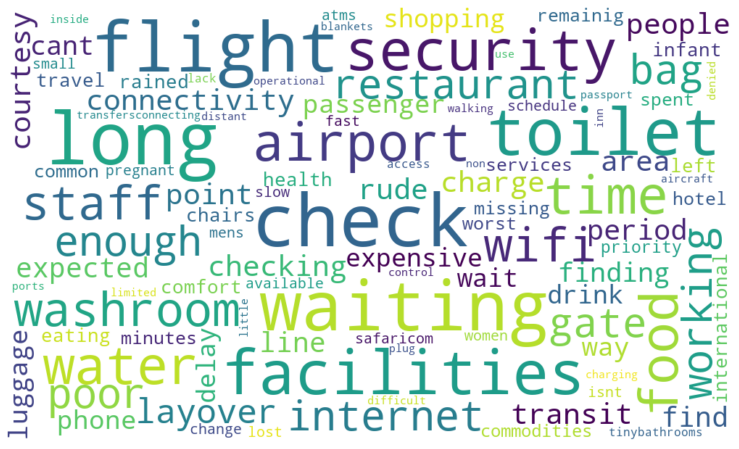

In [67]:
txt = ' '.join(rev for rev in Negative_sent.text)
plt.figure(figsize=(15,8))

wordcloud = WordCloud(
            background_color = 'white',
            max_font_size = 100,
            max_words = 100,
            width = 1000,
            height = 600
            ).generate(txt)


plt.imshow(wordcloud,interpolation = 'bilinear')

plt.axis('off')
plt.show()

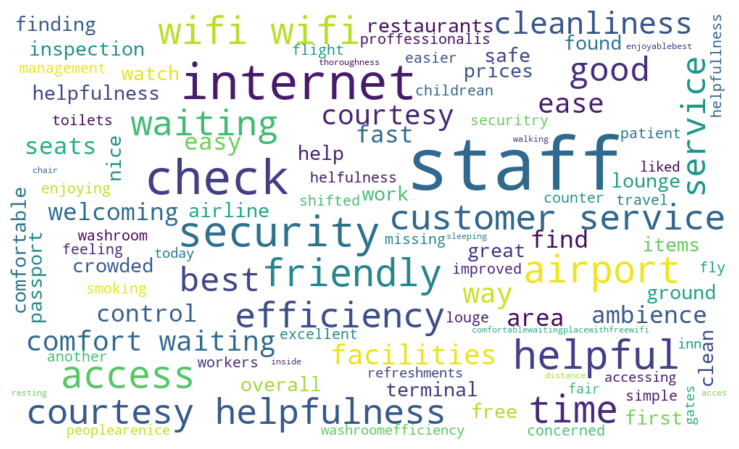

In [72]:
txt = ' '.join(rev for rev in Positive_sent.text)
plt.figure(figsize=(15,8))

wordcloud = WordCloud(
            background_color = 'white',
            max_font_size = 100,
            max_words = 100,
            width = 1000,
            height = 600
            ).generate(txt)


plt.imshow(wordcloud,interpolation = 'bilinear')
plt.axis('off')
plt.show()